# PSY 39200 Introduction to Computational Psychology and AI

## Week 03 Linear Algebra and Calculus  

## There are 5 sets of questions and 3 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### This Tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed): https://neuromatch.io/open-education-resources/

---
# Setup

Execute the following cells to set up the notebook environment

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#@title Figure settings
import ipywidgets as widgets  # interactive display
from ipywidgets import fixed
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/master/nma.mplstyle")

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# @title Plotting functions
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d


def visualize_vectors(v, v_unit):
  """ Plots a 2D vector and the corresponding unit vector

  Args:
    v (ndarray): array of size (2,) with the vector coordinates
    v_unit (ndarray): array of size (2, ) with the unit vector coordinates

  """
  fig, ax = plt.subplots()

  # Set up plot aesthetics
  ax.spines['top'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.set(xlim = [-6, 6], ylim = [-6, 6])
  ax.grid(True, alpha=.4, linewidth=1, zorder=0)

  # Plot vectors
  v_arr = ax.arrow(0, 0, v[0], v[1], width=0.08, color='#648FFF',
                   length_includes_head=True, zorder=2);
  v_unit_arr = ax.arrow(0, 0, v_unit[0], v_unit[1], width=0.08,
                        color='#DC267F',
                        length_includes_head=True, zorder=3);
  ax.set(xlim = [-4, 4], ylim = [-4, 4]);

  # Add legend
  leg = ax.legend([v_arr, v_unit_arr],
                  [r"Vector $\mathbf{v}$",
                   r"Normalized vector $\tilde{\mathbf{v}}$"],
                  fontsize=20, loc='upper left')


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
      FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
      self._verts3d = xs, ys, zs

    def draw(self, renderer):
      xs3d, ys3d, zs3d = self._verts3d
      xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)
      self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
      FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):
      xs3d, ys3d, zs3d = self._verts3d
      xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
      self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

In [ ]:
# @title Plotting functions
import numpy
from numpy.linalg import inv, eig
from math import ceil
from matplotlib import pyplot, ticker, get_backend, rc
from mpl_toolkits.mplot3d import Axes3D
from itertools import cycle

_int_backends = ['GTK3Agg', 'GTK3Cairo', 'MacOSX', 'nbAgg',
                 'Qt4Agg', 'Qt4Cairo', 'Qt5Agg', 'Qt5Cairo',
                 'TkAgg', 'TkCairo', 'WebAgg', 'WX', 'WXAgg', 'WXCairo']
_backend = get_backend()   # get current backend name

# shrink figsize and fontsize when using %matplotlib notebook
if _backend in _int_backends:
  fontsize = 4
  fig_scale = 0.75
else:
  fontsize = 5
  fig_scale = 1

grey = '#808080'
gold = '#cab18c'        # x-axis grid
lightblue = '#0096d6'   # y-axis grid
green = '#008367'       # x-axis basis vector
red = '#E31937'         # y-axis basis vector
darkblue = '#004065'

pink, yellow, orange, purple, brown = '#ef7b9d', '#fbd349', '#ffa500', '#a35cff', '#731d1d'

quiver_params = {'angles': 'xy',
                 'scale_units': 'xy',
                 'scale': 1,
                 'width': 0.012}

grid_params = {'linewidth': 0.5,
               'alpha': 0.8}

def set_rc(func):
  def wrapper(*args, **kwargs):
    rc('font', family='serif', size=fontsize)
    rc('figure', dpi=200)
    rc('axes', axisbelow=True, titlesize=5)
    rc('lines', linewidth=1)
    func(*args, **kwargs)
  return wrapper

@set_rc
def plot_vector(vectors, tails=None):
  ''' Draw 2d vectors based on the values of the vectors and the position of their tails.

  Parameters
  ----------
  vectors : list.
    List of 2-element array-like structures, each represents a 2d vector.

  tails : list, optional.
    List of 2-element array-like structures, each represents the coordinates of the tail
    of the corresponding vector in vectors. If None (default), all tails are set at the
    origin (0,0). If len(tails) is 1, all tails are set at the same position. Otherwise,
    vectors and tails must have the same length.

  Examples
  --------
  >>> v = [(1, 3), (3, 3), (4, 6)]
  >>> plot_vector(v)      # draw 3 vectors with their tails at origin
  >>> t = [numpy.array((2, 2))]
  >>> plot_vector(v, t)   # draw 3 vectors with their tails at (2,2)
  >>> t = [[3, 2], [-1, -2], [3, 5]]
  >>> plot_vector(v, t)   # draw 3 vectors with 3 different tails

  '''
  vectors = numpy.array(vectors)
  assert vectors.shape[1] == 2, "Each vector should have 2 elements."
  if tails is not None:
    tails = numpy.array(tails)
    assert tails.shape[1] == 2, "Each tail should have 2 elements."
  else:
    tails = numpy.zeros_like(vectors)

  # tile vectors or tails array if needed
  nvectors = vectors.shape[0]
  ntails = tails.shape[0]
  if nvectors == 1 and ntails > 1:
    vectors = numpy.tile(vectors, (ntails, 1))
  elif ntails == 1 and nvectors > 1:
    tails = numpy.tile(tails, (nvectors, 1))
  else:
    assert tails.shape == vectors.shape, "vectors and tail must have a same shape"

  # calculate xlimit & ylimit
  heads = tails + vectors
  limit = numpy.max(numpy.abs(numpy.hstack((tails, heads))))
  limit = numpy.ceil(limit * 1.2)   # add some margins

  figsize = numpy.array([2,2]) * fig_scale
  figure, axis = pyplot.subplots(figsize=figsize)
  axis.quiver(tails[:,0], tails[:,1], vectors[:,0], vectors[:,1], color=darkblue,
                  angles='xy', scale_units='xy', scale=1)
  axis.set_xlim([-limit, limit])
  axis.set_ylim([-limit, limit])
  axis.set_aspect('equal')

  # if xticks and yticks of grid do not match, choose the finer one
  xticks = axis.get_xticks()
  yticks = axis.get_yticks()
  dx = xticks[1] - xticks[0]
  dy = yticks[1] - yticks[0]
  base = max(int(min(dx, dy)), 1)   # grid interval is always an integer
  loc = ticker.MultipleLocator(base=base)
  axis.xaxis.set_major_locator(loc)
  axis.yaxis.set_major_locator(loc)
  axis.grid(True, **grid_params)

  # show x-y axis in the center, hide frames
  axis.spines['left'].set_position('center')
  axis.spines['bottom'].set_position('center')
  axis.spines['right'].set_color('none')
  axis.spines['top'].set_color('none')

@set_rc
def plot_transformation_helper(axis, matrix, *vectors, unit_vector=True, unit_circle=False, title=None):
  """ A helper function to plot the linear transformation defined by a 2x2 matrix.

  Parameters
  ----------
  axis : class matplotlib.axes.Axes.
    The axes to plot on.

  matrix : class numpy.ndarray.
    The 2x2 matrix to visualize.

  *vectors : class numpy.ndarray.
    The vector(s) to plot along with the linear transformation. Each array denotes a vector's
    coordinates before the transformation and must have a shape of (2,). Accept any number of vectors.

  unit_vector : bool, optional.
    Whether to plot unit vectors of the standard basis, default to True.

  unit_circle: bool, optional.
    Whether to plot unit circle, default to False.

  title: str, optional.
    Title of the plot.

  """
  assert matrix.shape == (2,2), "the input matrix must have a shape of (2,2)"
  grid_range = 20
  x = numpy.arange(-grid_range, grid_range+1)
  X_, Y_ = numpy.meshgrid(x,x)
  I = matrix[:,0]
  J = matrix[:,1]
  X = I[0]*X_ + J[0]*Y_
  Y = I[1]*X_ + J[1]*Y_
  origin = numpy.zeros(1)

  # draw grid lines
  for i in range(x.size):
    axis.plot(X[i,:], Y[i,:], c=gold, **grid_params)
    axis.plot(X[:,i], Y[:,i], c=lightblue, **grid_params)

  # draw (transformed) unit vectors
  if unit_vector:
    axis.quiver(origin, origin, [I[0]], [I[1]], color=green, **quiver_params)
    axis.quiver(origin, origin, [J[0]], [J[1]], color=red, **quiver_params)

  # draw optional vectors
  color_cycle = cycle([pink, darkblue, orange, purple, brown])
  if vectors:
    for vector in vectors:
      color = next(color_cycle)
      vector_ = matrix @ vector.reshape(-1,1)
      axis.quiver(origin, origin, [vector_[0]], [vector_[1]], color=color, **quiver_params)

  # draw optional unit circle
  if unit_circle:
    alpha =  numpy.linspace(0, 2*numpy.pi, 41)
    circle = numpy.vstack((numpy.cos(alpha), numpy.sin(alpha)))
    circle_trans = matrix @ circle
    axis.plot(circle_trans[0], circle_trans[1], color=red, lw=0.8)

  # hide frames, set xlimit & ylimit, set title
  limit = 4
  axis.spines['left'].set_position('center')
  axis.spines['bottom'].set_position('center')
  axis.spines['left'].set_linewidth(0.3)
  axis.spines['bottom'].set_linewidth(0.3)
  axis.spines['right'].set_color('none')
  axis.spines['top'].set_color('none')
  axis.set_xlim([-limit, limit])
  axis.set_ylim([-limit, limit])
  if title is not None:
    axis.set_title(title)

@set_rc
def plot_linear_transformation(matrix, *vectors, name = None, unit_vector=True, unit_circle=False):
  """ Plot the linear transformation defined by a 2x2 matrix using the helper
  function plot_transformation_helper(). It will create 2 subplots to visualize some
  vectors before and after the transformation.

  Parameters
  ----------
  matrix : class numpy.ndarray.
    The 2x2 matrix to visualize.

  *vectors : class numpy.ndarray.
    The vector(s) to plot along with the linear transformation. Each array denotes a vector's
    coordinates before the transformation and must have a shape of (2,). Accept any number of vectors.

  unit_vector : bool, optional.
    Whether to plot unit vectors of the standard basis, default to True.

  unit_circle: bool, optional.
    Whether to plot unit circle, default to False.

  """
  figsize = numpy.array([4,2]) * fig_scale
  figure, (axis1, axis2) = pyplot.subplots(1, 2, figsize=figsize)
  plot_transformation_helper(axis1, numpy.identity(2), *vectors, unit_vector=unit_vector, unit_circle=unit_circle, title='Before transformation')
  plot_transformation_helper(axis2, matrix, *vectors, unit_vector=unit_vector, unit_circle=unit_circle, title='After transformation')
  if name is not None:
    figure.suptitle(f'Population {name}')


def plot_eig_vec_transform(W):
  classic = 'k'
  vec_names = ['a', 'b','c','d','e','f','g', 'h']

  _, vecs = np.linalg.eig(W)
  vecs = vecs.T

  fig, axes = plt.subplots(1, 2, figsize=(2, 1))
  colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

  for i in range(2):
    axes[i].set(xlim=[-3.5, 3.5], ylim=[-3.5,3.5])
    axes[i].axis('Off')
    axes[i].plot([0, 0], [-3.5, 3.5], classic, alpha=.4)
    axes[i].plot([-3.5, 3.5], [0, 0], classic, alpha=.4)

  for i_vec, vec in enumerate(vecs):
    axes[0].arrow(0, 0, vec[0], vec[1], head_width=.2, facecolor=colors[i_vec], edgecolor=colors[i_vec], length_includes_head=True)
    axes[0].annotate(vec_names[i_vec], xy=(vec[0]+np.sign(vec[0])*.15, vec[1]+np.sign(vec[1])*.15), color=colors[i_vec])

    transformed_vec = np.matmul(W, vec)
    axes[1].arrow(0, 0, transformed_vec[0], transformed_vec[1], head_width=.2, facecolor=colors[i_vec], edgecolor=colors[i_vec], length_includes_head=True)
    axes[1].annotate(vec_names[i_vec], xy=(transformed_vec[0]+np.sign(transformed_vec[0])*.15, transformed_vec[1]+np.sign(transformed_vec[1])*.15), color=colors[i_vec])

  axes[0].set_title('Before')
  axes[1].set_title('After')

# Discussion Part 1

---

# Section 1: Intro to vectors

## Section 1.1: What is a vector?



## Example: Vectors in Computational Psychology and AI

A **vector** can represent information in both the brain and artificial neural networks.

Example: a stimulus (e.g., the firing rates of multiple neurons) can be represented as a vector:

$$
\mathbf{v} =
\begin{bmatrix}
12.3 \\
5.1 \\
0.0 \\
8.7 \\
\vdots \\
0.05
\end{bmatrix}
$$

In **computational cognitive neuroscience**, **each element of the vector** can represent the **firing rate** of a neuron or a neural population responding to the stimulus.


In **artificial intelligence**, the same vector can represent a **learned feature embedding** produced by a neural network, where each dimension encodes the activity of an artificial neuron.


Vectors that are **close to each other** represent **similar stimuli**, while vectors that are **far apart** represent **different stimuli**.

### Summary   

In both computational psychology (cognitive neuroscience) and AI, a vector is a numerical representation that encode information in high-dimensional spaces (the number of dimensions is the number of components in a vector).  


## Section 1.2: Vector operations

## Basic Operations on Vectors

We commonly perform several mathematical operations on vectors.

---

## Length of a Vector

The **length** of a vector (also called its **magnitude** or **norm**) measures how long the vector is.

For a vector $\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_N
\end{bmatrix}$,
its length is defined as:

$$
\|\mathbf{x}\| = \sqrt{x_1^2 + x_2^2 + \cdots + x_N^2}
$$

---

### Scalar Multiplication

**Scalar multiplication** changes the **length** of a vector without changing its direction  
(except when the scalar is negative, which reverses the direction).

Multiplying a vector $\mathbf{x}$ by a scalar $a$:

$$
a\mathbf{x} =
\begin{bmatrix}
a x_1 \\
a x_2 \\
\vdots \\
a x_N
\end{bmatrix}
$$

---

### Vector Addition

**Vector addition** combines two vectors by adding their corresponding components.

Geometrically, vector addition can be visualized by placing the tail of one vector at the head of the other, or by forming a parallelogram.

Numerically:

$$
\mathbf{x} + \mathbf{y} =
\begin{bmatrix}
x_1 + y_1 \\
x_2 + y_2 \\
\vdots \\
x_N + y_N
\end{bmatrix}
$$

---

### Linear Combination

A **linear combination** is formed by multiplying vectors by scalars and then adding them together.

A vector $\mathbf{u}$ is a linear combination of vectors $\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_N$ if:

$$
\mathbf{u} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_N \mathbf{v}_N
$$

The result of a linear combination is **another vector** in the same space.


### Interactive Demo: Linear combination of vectors
In the following demo, we will demonstrate a linear combination of two vectors, $\mathbf{x}$ and $\mathbf{y}$.

\begin{equation}
\mathbf{z} = a\mathbf{x} + b\mathbf{y}
\end{equation}

where $\mathbf{x} = \begin{bmatrix}3 \\ 1 \end{bmatrix}$ and $\mathbf{y} = \begin{bmatrix}-1 \\ 2 \end{bmatrix}$.

You will play with the scalar multiples $a$ and $b$ to visualize both scalar multiplication and vector addition.



In [ ]:
 #@markdown Make sure you execute this cell to enable the widget! Move the sliders for “a” and “b”. After releasing the slider, be patient for a couple of seconds to see the desired change.


def plot_arrows(x, y, a_times_x, b_times_y):
  fig, ax = plt.subplots(figsize=(10, 7))

  ax.spines['top'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')

  ax.set_aspect('equal', adjustable='box')
  ax.set(xlim = [-10, 10], ylim = [-10, 10], xticks = np.arange(-10, 10), yticks = np.arange(-10, 10), xticklabels = [], yticklabels = [])

  ax.grid(alpha=.4)

  z = a_times_x + b_times_y
  z_arr = ax.arrow(0, 0, z[0], z[1], width=.08, color='k', length_includes_head = True);

  x_orig, = ax.plot([0, x[0]], [0, x[1]], '--', color='#648FFF')
  y_orig, = ax.plot([0, y[0]], [0, y[1]], '--',  color='#DC267F')

  ax_arr = ax.arrow(0, 0, a_times_x[0], a_times_x[1], width=.08, color='#648FFF', length_includes_head = True);
  by_arr = ax.arrow(0, 0, b_times_y[0], b_times_y[1], width=.08, color='#DC267F', length_includes_head = True);

  ax.plot([a_times_x[0], z[0]], [a_times_x[1], z[1]], '--k')
  ax.plot([b_times_y[0], z[0]], [b_times_y[1], z[1]], '--k')


  leg = ax.legend([x_orig, y_orig, ax_arr, by_arr, z_arr], [r"$\mathbf{x}$", r"$\mathbf{y}$", r"$a\mathbf{x}$", r"$b\mathbf{y}$", r"$\mathbf{z} = a\mathbf{x} + b\mathbf{y}$"], handlelength = 2, fontsize = 25, loc = 'center left', bbox_to_anchor=(1.05, .5))

@widgets.interact(a = widgets.FloatSlider(value=1.0, min=-2, max=2, step=0.1), b = widgets.FloatSlider(value=1.0, min=-2, max=2, step=0.1))
def plot_linear_combination(a, b):
  x = np.array([3, 1])
  y = np.array([-1, 2])

  plot_arrows(x, y, a*x, b*y)

interactive(children=(FloatSlider(value=1.0, description='a', max=2.0, min=-2.0), FloatSlider(value=1.0, descr…

# Question 1

Think and answer the following questions:

1. How does $a\mathbf{x}$ compare to $\mathbf{x}$ when $a$ is negative?
2. How does $a\mathbf{x}$ compare to $\mathbf{x}$ when $a$ is a fraction?
3. Can you get $\mathbf{z}$ to point to anywhere in the 2D space with combinations of $a$ and $b$?
4. Would this be the case no matter what $\mathbf{x}$ and $\mathbf{y}$ are, as long as they are both 2D vectors?

1. The ax vector is a times x in length and in opposite direction of x
2. The ax vector is a times x in length, when a is a simple fraction (ranging from 0-1) it will decrease the length of the vector
3. Yes
4. Yes, except for when x aand y are null by itself or with multiplying a and b with it, this makes the vector transform into a point with no direction.

# Section 2: The dot product

## Section 2.1: Neural modeling using the dot product

## Dot Product

The **dot product** between two vectors produces a **scalar** by multiplying corresponding components and summing the results:

$$
\mathbf{x} \cdot \mathbf{y} = \sum_{i=1}^{N} x_i y_i
$$

---

### Example

For
$$
\mathbf{x} =
\begin{bmatrix}
2 \\
3
\end{bmatrix},
\quad
\mathbf{y} =
\begin{bmatrix}
1 \\
4
\end{bmatrix}
$$

the dot product is:

$$
\mathbf{x} \cdot \mathbf{y} = 2 \times 1 + 3 \times 4 = 14
$$

---

### Interpretation in Neuroscience and AI

The dot product models a **weighted sum**.

In neuroscience, it can represent the firing rate of a neuron receiving inputs from other neurons:

- $\mathbf{r}$ = vector of retinal neuron firing rates  
- $\mathbf{w}$ = vector of synaptic weights  

The output firing rate of an LGN neuron is:

$$
g = \mathbf{w} \cdot \mathbf{r} = w_1 r_1 + w_2 r_2
$$

This same operation is also used in **artificial neural networks**, where neuron activations are computed as dot products between input vectors and weight vectors.

---

### Summary

The dot product computes how strongly one vector influences another through a weighted sum.



<figure>
<img src="https://raw.githubusercontent.com/NeuromatchAcademy/precourse/main/tutorials/W0D3_LinearAlgebra/static/nodes.png">
</figure>

### Interactive Demo 3.1: LGN firing


In the following demo you will try various combinations of firing rates of the retinal neurons (thus moving the vector that corresponds to the firing rates).  When you move the retinal firing rates around, you will see the heatmap in that area appear, which shows the corresponding LGN neuron firing rate (for that combo of retina firing). Remember that this value is computed as the dot product between the retinal firing rate vector and the weight vector.



In [ ]:
#@markdown Make sure you execute this cell to enable the widget!

step = .1
x_vec = np.arange(-4, 4.001, step)
y_vec = np.arange(-4, 4.001, step)
n_pixels = x_vec.shape[0]


heatmap = np.zeros((n_pixels, n_pixels))
y = np.array([1, 3])
for i, coord1 in enumerate(x_vec):
  for j, coord2 in enumerate(x_vec):
    heatmap[i, j] = np.dot(np.array([coord1, coord2]), y)
circle_mask = np.zeros((n_pixels, n_pixels))

for i, coord_i in enumerate(x_vec):
  for j, coord_j in enumerate(y_vec):
    circle_mask[i, j] = np.sqrt(coord_i**2 + coord_j**2)

circle_mask = circle_mask < 4

heatmap = heatmap * circle_mask
mask = np.zeros((n_pixels, n_pixels))

def plot_heatmap(x, y, mask):

  fig, ax = plt.subplots()

  ax.spines['top'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')

  heatmap[np.where(x_vec == x[0])[0], np.where(x_vec == x[1])[0]] = np.dot(x, y)

  masked_x = np.abs(x_vec - x[0]) < 1
  masked_y = np.abs(y_vec - x[1]) < 1
  mask += np.outer(masked_x, masked_y)
  mask = np.minimum(mask, 1)

  im = ax.imshow((heatmap * mask).T, vmin = -15, vmax = 15, origin = 'lower', alpha = .5, extent=[-n_pixels/2., n_pixels/2., -n_pixels/2., n_pixels/2. ], cmap = 'bwr')
  cbar = plt.colorbar(im, ax = ax)
  cbar.set_label('Response of LGN neuron (g)', rotation=270, labelpad=20)
  ax.set(xticklabels = [], yticklabels = [], xlabel = '$\mathbf{r}_1$')
  ax.set_ylabel('$\mathbf{r}_2$', rotation=0)

  ax.xaxis.set_label_coords(0, .45)
  ax.yaxis.set_label_coords(.5, 1)
  fr_arr = ax.arrow(0, 0, (1/step)*x[0], (1/step)*x[1], width=.5, color='#40B0A6', length_includes_head = True);
  we_arr = ax.arrow(0, 0, (1/step)*y[0], (1/step)*y[1], width=.5, color='k', length_includes_head = True);


  leg = ax.legend([fr_arr, we_arr], ['Retina firing rate vector', 'Weight vector'],
                  handlelength = 0, frameon=False, fontsize = 17,loc = 'center',
                  bbox_to_anchor=(.5, -.1))

  return mask

style = {'description_width': 'initial'}

@widgets.interact(neuron1_firing = widgets.FloatSlider(value=1.0, min=-4, max=4, step=1, style=style), neuron2_firing = widgets.FloatSlider(value=1.0, min=-4, max=4, step=1, style=style), mask = fixed(mask),  heatmap = fixed(heatmap))
def plot_linear_combination(neuron1_firing, neuron2_firing, mask):
  firing_rates = np.array([neuron1_firing, neuron2_firing])
  weights = np.array([1, 2])
  mask = plot_heatmap(firing_rates, weights, mask)

interactive(children=(FloatSlider(value=1.0, description='neuron1_firing', max=4.0, min=-4.0, step=1.0, style=…

# Question 2   

Play with the following demo and then answer these questions:


1.   For a given length of the retinal firing rate vector, what direction maximally excites the LGN neuron (highest postsynaptic firing rate)? How does it relate to the weights vector?
2.   For a given length of the retinal firing rate vector, what direction minimally excites the LGN neuron?
3.   When does the LGN neuron have 0 firing rate? What is the relationship between the weights and retinal firing rate vector?
4.   For a given direction, how does the LGN firing rate vary with length of the retinal firing rate vector?
5.   Let's say the retinal neurons are tightly linked and the length of the retinal firing rate vector has to be 1. In other words, it has to be a unit vector. How would you find the retinal firing rates that maximally excite the LGN neuron?

1. In the first quadrant, in the top right direction, 45 degrees. Higher the length of weights higher the excitation of the LGN neuron.
2. In the third quadrant, in the bottom left direction, 225 degrees.
3. LGN firing rate is 0 in the second and the fouth quandrant (it is a line going through the origin and perpendicular to the weight vector)
4. Except for the direction perpendicular to weight vector (where the length of the retinal firing rate vector does not affect the LGN firing rate and where the value is 0), the LGN firing rate increases (above the perpendicular line) and decreases (below the perpendicular line) when there is increase in length of retinal firing rate vector
5. It should be all the vectors which lie on the top circumference of the circle

## Section 2.2: The geometry of the dot product


An alternate way of defining the dot product is as the multiple of the lengths of the two vectors and the angle between them $\theta$:

\begin{equation}
\mathbf{x} \cdot \mathbf{y} = ||\mathbf{x}|| \cdot ||\mathbf{y}|| \cdot \text{cos}\theta
\end{equation}

This means that:

- the dot product is largest when the vectors are the same direction (angle $0^{\text{o}}$)

- the dot product is smallest when the vectors are the opposite direction (angle $180^{\text{o}}$)

- the dot product is 0 when the vectors are perpendicular (angle $90^{\text{o}}$)

- for fixed vector lengths, the **dot product is a measure of similarity between the vectors**

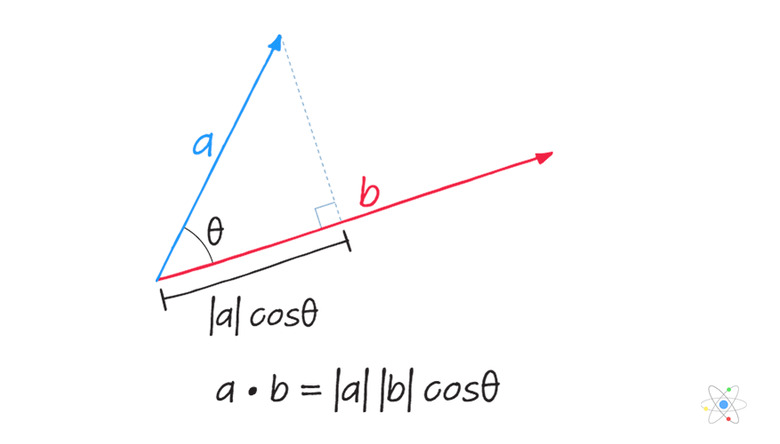

Picture from https://www.sciencing.com/dot-product-vector-definition-formula-how-to-find-w-diagrams-examples-13720224/

# Question 3

How can we use dot product to compare the similarity of two internal neural representations (two vectors, each containing the firing rates of N neurons)?

Treating each population response as a vector of firing rates and compute their dot product, which sums how strongly corresponding neurons fire together across the two representations. A larger dot product means greater overlap in active neurons and thus higher similarity. If you normalize by the vector magnitudes (cosine similarity), the measure reflects similarity of the firing pattern independent of overall firing strength.

# Section 3 Matrix

In neuroscience, a **matrix** is often used to model the **connections between neurons**.

Suppose we have:
- an input population of $N$ neurons with firing rates  
  $$\mathbf{r} \in \mathbb{R}^{N}$$
- an output population of $M$ neurons with firing rates  
  $$\mathbf{g} \in \mathbb{R}^{M}$$

The synaptic connections between the two populations are represented by a **weight matrix**:

$$
\mathbf{W} \in \mathbb{R}^{M \times N}
$$

---

### Neural Transformation

Each element $W_{ij}$ represents the strength of the synapse from **input neuron $j$** to **output neuron $i$**.

The output firing rates are computed as:

$$
\mathbf{g} = \mathbf{W}\mathbf{r}
$$

---

### Interpretation

- The **vector** $\mathbf{r}$ represents neural activity in the input population  
- The **matrix** $\mathbf{W}$ represents connectivity between populations  
- The resulting **vector** $\mathbf{g}$ represents activity in the output population  

This operation models how neural activity is **transformed** as it propagates through a neural circuit.

---

### Summary

A **matrix** encodes **synaptic connections** that **transform** one neural population activity vector into another.


In [ ]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
from ipywidgets import fixed
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [ ]:
# @title Plotting functions
import numpy
from numpy.linalg import inv, eig
from math import ceil
from matplotlib import pyplot, ticker, get_backend, rc
from mpl_toolkits.mplot3d import Axes3D
from itertools import cycle

_int_backends = ['GTK3Agg', 'GTK3Cairo', 'MacOSX', 'nbAgg',
                 'Qt4Agg', 'Qt4Cairo', 'Qt5Agg', 'Qt5Cairo',
                 'TkAgg', 'TkCairo', 'WebAgg', 'WX', 'WXAgg', 'WXCairo']
_backend = get_backend()   # get current backend name

# shrink figsize and fontsize when using %matplotlib notebook
if _backend in _int_backends:
  fontsize = 4
  fig_scale = 0.75
else:
  fontsize = 5
  fig_scale = 1

grey = '#808080'
gold = '#cab18c'        # x-axis grid
lightblue = '#0096d6'   # y-axis grid
green = '#008367'       # x-axis basis vector
red = '#E31937'         # y-axis basis vector
darkblue = '#004065'

pink, yellow, orange, purple, brown = '#ef7b9d', '#fbd349', '#ffa500', '#a35cff', '#731d1d'

quiver_params = {'angles': 'xy',
                 'scale_units': 'xy',
                 'scale': 1,
                 'width': 0.012}

grid_params = {'linewidth': 0.5,
               'alpha': 0.8}

def set_rc(func):
  def wrapper(*args, **kwargs):
    rc('font', family='serif', size=fontsize)
    rc('figure', dpi=200)
    rc('axes', axisbelow=True, titlesize=5)
    rc('lines', linewidth=1)
    func(*args, **kwargs)
  return wrapper

@set_rc
def plot_vector(vectors, tails=None):
  ''' Draw 2d vectors based on the values of the vectors and the position of their tails.

  Parameters
  ----------
  vectors : list.
    List of 2-element array-like structures, each represents a 2d vector.

  tails : list, optional.
    List of 2-element array-like structures, each represents the coordinates of the tail
    of the corresponding vector in vectors. If None (default), all tails are set at the
    origin (0,0). If len(tails) is 1, all tails are set at the same position. Otherwise,
    vectors and tails must have the same length.

  Examples
  --------
  >>> v = [(1, 3), (3, 3), (4, 6)]
  >>> plot_vector(v)      # draw 3 vectors with their tails at origin
  >>> t = [numpy.array((2, 2))]
  >>> plot_vector(v, t)   # draw 3 vectors with their tails at (2,2)
  >>> t = [[3, 2], [-1, -2], [3, 5]]
  >>> plot_vector(v, t)   # draw 3 vectors with 3 different tails

  '''
  vectors = numpy.array(vectors)
  assert vectors.shape[1] == 2, "Each vector should have 2 elements."
  if tails is not None:
    tails = numpy.array(tails)
    assert tails.shape[1] == 2, "Each tail should have 2 elements."
  else:
    tails = numpy.zeros_like(vectors)

  # tile vectors or tails array if needed
  nvectors = vectors.shape[0]
  ntails = tails.shape[0]
  if nvectors == 1 and ntails > 1:
    vectors = numpy.tile(vectors, (ntails, 1))
  elif ntails == 1 and nvectors > 1:
    tails = numpy.tile(tails, (nvectors, 1))
  else:
    assert tails.shape == vectors.shape, "vectors and tail must have a same shape"

  # calculate xlimit & ylimit
  heads = tails + vectors
  limit = numpy.max(numpy.abs(numpy.hstack((tails, heads))))
  limit = numpy.ceil(limit * 1.2)   # add some margins

  figsize = numpy.array([2,2]) * fig_scale
  figure, axis = pyplot.subplots(figsize=figsize)
  axis.quiver(tails[:,0], tails[:,1], vectors[:,0], vectors[:,1], color=darkblue,
                  angles='xy', scale_units='xy', scale=1)
  axis.set_xlim([-limit, limit])
  axis.set_ylim([-limit, limit])
  axis.set_aspect('equal')

  # if xticks and yticks of grid do not match, choose the finer one
  xticks = axis.get_xticks()
  yticks = axis.get_yticks()
  dx = xticks[1] - xticks[0]
  dy = yticks[1] - yticks[0]
  base = max(int(min(dx, dy)), 1)   # grid interval is always an integer
  loc = ticker.MultipleLocator(base=base)
  axis.xaxis.set_major_locator(loc)
  axis.yaxis.set_major_locator(loc)
  axis.grid(True, **grid_params)

  # show x-y axis in the center, hide frames
  axis.spines['left'].set_position('center')
  axis.spines['bottom'].set_position('center')
  axis.spines['right'].set_color('none')
  axis.spines['top'].set_color('none')

@set_rc
def plot_transformation_helper(axis, matrix, *vectors, unit_vector=True, unit_circle=False, title=None):
  """ A helper function to plot the linear transformation defined by a 2x2 matrix.

  Parameters
  ----------
  axis : class matplotlib.axes.Axes.
    The axes to plot on.

  matrix : class numpy.ndarray.
    The 2x2 matrix to visualize.

  *vectors : class numpy.ndarray.
    The vector(s) to plot along with the linear transformation. Each array denotes a vector's
    coordinates before the transformation and must have a shape of (2,). Accept any number of vectors.

  unit_vector : bool, optional.
    Whether to plot unit vectors of the standard basis, default to True.

  unit_circle: bool, optional.
    Whether to plot unit circle, default to False.

  title: str, optional.
    Title of the plot.

  """
  assert matrix.shape == (2,2), "the input matrix must have a shape of (2,2)"
  grid_range = 20
  x = numpy.arange(-grid_range, grid_range+1)
  X_, Y_ = numpy.meshgrid(x,x)
  I = matrix[:,0]
  J = matrix[:,1]
  X = I[0]*X_ + J[0]*Y_
  Y = I[1]*X_ + J[1]*Y_
  origin = numpy.zeros(1)

  # draw grid lines
  for i in range(x.size):
    axis.plot(X[i,:], Y[i,:], c=gold, **grid_params)
    axis.plot(X[:,i], Y[:,i], c=lightblue, **grid_params)

  # draw (transformed) unit vectors
  if unit_vector:
    axis.quiver(origin, origin, [I[0]], [I[1]], color=green, **quiver_params)
    axis.quiver(origin, origin, [J[0]], [J[1]], color=red, **quiver_params)

  # draw optional vectors
  color_cycle = cycle([pink, darkblue, orange, purple, brown])
  if vectors:
    for vector in vectors:
      color = next(color_cycle)
      vector_ = matrix @ vector.reshape(-1,1)
      axis.quiver(origin, origin, [vector_[0]], [vector_[1]], color=color, **quiver_params)

  # draw optional unit circle
  if unit_circle:
    alpha =  numpy.linspace(0, 2*numpy.pi, 41)
    circle = numpy.vstack((numpy.cos(alpha), numpy.sin(alpha)))
    circle_trans = matrix @ circle
    axis.plot(circle_trans[0], circle_trans[1], color=red, lw=0.8)

  # hide frames, set xlimit & ylimit, set title
  limit = 4
  axis.spines['left'].set_position('center')
  axis.spines['bottom'].set_position('center')
  axis.spines['left'].set_linewidth(0.3)
  axis.spines['bottom'].set_linewidth(0.3)
  axis.spines['right'].set_color('none')
  axis.spines['top'].set_color('none')
  axis.set_xlim([-limit, limit])
  axis.set_ylim([-limit, limit])
  if title is not None:
    axis.set_title(title)

@set_rc
def plot_linear_transformation(matrix, *vectors, name = None, unit_vector=True, unit_circle=False):
  """ Plot the linear transformation defined by a 2x2 matrix using the helper
  function plot_transformation_helper(). It will create 2 subplots to visualize some
  vectors before and after the transformation.

  Parameters
  ----------
  matrix : class numpy.ndarray.
    The 2x2 matrix to visualize.

  *vectors : class numpy.ndarray.
    The vector(s) to plot along with the linear transformation. Each array denotes a vector's
    coordinates before the transformation and must have a shape of (2,). Accept any number of vectors.

  unit_vector : bool, optional.
    Whether to plot unit vectors of the standard basis, default to True.

  unit_circle: bool, optional.
    Whether to plot unit circle, default to False.

  """
  figsize = numpy.array([4,2]) * fig_scale
  figure, (axis1, axis2) = pyplot.subplots(1, 2, figsize=figsize)
  plot_transformation_helper(axis1, numpy.identity(2), *vectors, unit_vector=unit_vector, unit_circle=unit_circle, title='Before transformation')
  plot_transformation_helper(axis2, matrix, *vectors, unit_vector=unit_vector, unit_circle=unit_circle, title='After transformation')
  if name is not None:
    figure.suptitle(f'Population {name}')



def plot_eig_vec_transform(W, figsize=(8, 4), dpi=200, title_fs=10, label_fs=10):
  classic = 'k'
  vec_names = ['a', 'b','c','d','e','f','g', 'h']

  _, vecs = np.linalg.eig(W)
  vecs = vecs.T

  fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
  colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

  for i in range(2):
    axes[i].set(xlim=[-3.5, 3.5], ylim=[-3.5, 3.5])
    axes[i].axis('off')
    axes[i].plot([0, 0], [-3.5, 3.5], classic, alpha=.4)
    axes[i].plot([-3.5, 3.5], [0, 0], classic, alpha=.4)

  for i_vec, vec in enumerate(vecs):
    axes[0].arrow(0, 0, vec[0], vec[1],
                  head_width=.2, length_includes_head=True,
                  facecolor=colors[i_vec], edgecolor=colors[i_vec])
    axes[0].annotate(vec_names[i_vec],
                     xy=(vec[0]+np.sign(vec[0])*.15, vec[1]+np.sign(vec[1])*.15),
                     color=colors[i_vec], fontsize=label_fs)

    transformed_vec = W @ vec
    axes[1].arrow(0, 0, transformed_vec[0], transformed_vec[1],
                  head_width=.2, length_includes_head=True,
                  facecolor=colors[i_vec], edgecolor=colors[i_vec])
    axes[1].annotate(vec_names[i_vec],
                     xy=(transformed_vec[0]+np.sign(transformed_vec[0])*.15,
                         transformed_vec[1]+np.sign(transformed_vec[1])*.15),
                     color=colors[i_vec], fontsize=label_fs)

  axes[0].set_title('Before', fontsize=title_fs)
  axes[1].set_title('After', fontsize=title_fs)
  fig.tight_layout()
  return fig, axes

# Coding Exercise 1: Understanding neural transformations

We will look at a group of 2 LGN neurons which get input from 2 retinal neurons: we will call the population of LGN neurons population $p$. Below, we have the system of linear equations that dictates the neuron models for each population. $r_1$ and $r_2$ correspond to the retinal neural activities (of neuron 1 and 2). $g_{p_1}$ and  $g_{p_2}$ correspond to the responses of the LGN neurons 1 and 2 in population $p$.

\begin{align}
r_1 + 3r_2 &= g_{p_1} \\
2r_1 + r_2 &= g_{p_2}
\end{align}

<br>

1) Cast each equation (i.e., $g_{p_1}$ and $g_{p_2}$) as a matrix-vector multiplication:

\begin{equation}
\mathbf{g}_p = \mathbf{P}\mathbf{r}
\end{equation}

where $P$ is the weight matrix to population $p$.

2) Let's say we only recorded from the LGN cells (and know the weight matrix) and are trying to figure out how the retinal cells responded. Solve the matrix equation for the given LGN activities:

\begin{equation}
\mathbf{g}_p =
\begin{bmatrix}
16 \\
7
\end{bmatrix}
\end{equation}

<br>

**Note:** In Python, we can use the `@` operator for matrix/vector multiplications. We can also use the NumPy [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html#numpy.dot), [`np.matmul`](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html). See the documentation for their differences.

In [ ]:
# Create P (using np array)
P = np.array([[1, 3], [2, 1]])

# Create g_p (using np array)
g_p = np.array([16, 7])

# Solve for r (using np.linalg.inv)
r = np.linalg.inv(P) @ g_p

# Print r
print(r)


[1. 5.]


You should see the output `[1, 5]`.

## Section 3.1: Matrices as linear transformations


## Matrices as Linear Transformations

A **matrix** can be thought of as performing a **linear transformation**.

When a matrix multiplies a vector, it **transforms** that vector into another vector:

$$
\mathbf{y} = \mathbf{W}\mathbf{x}
$$

---

### Example 1: Transforming a Vector

Let
$$
\mathbf{W} =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix},
\quad
\mathbf{x} =
\begin{bmatrix}
1 \\
1
\end{bmatrix}
$$

Then
$$
\mathbf{y} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

This transformation **stretches space horizontally** while leaving the vertical direction unchanged.

---

### Example 2: Transforming a Grid of Space

Instead of thinking about a single vector, imagine applying the matrix to **every vector in space**.

Under a linear transformation:
- the **origin remains fixed**
- **straight lines remain straight**
- **parallel lines remain parallel**
- **evenly spaced grid lines remain evenly spaced**

The entire coordinate grid is smoothly stretched, compressed, rotated, or sheared.

---

### Example 3: Neuroscience Interpretation

In neuroscience, a weight matrix transforms activity from one neural population into another:

$$
\mathbf{g} = \mathbf{W}\mathbf{r}
$$

- $\mathbf{r}$: firing rates of input neurons  
- $\mathbf{W}$: synaptic connectivity matrix  
- $\mathbf{g}$: firing rates of output neurons  

Each output neuron computes a weighted combination of inputs, forming a **linear transformation** of population activity.

---

### Summary

A matrix defines how vectors—and the space they live in—are transformed in a linear way.


---
## Section 3.2: Matrix multiplication





We sometimes want to multiple two matrices together, instead of a matrix with a vector. Let's say we're multiplying matrices $\mathbf{A}$ and $\mathbf{B}$ to get $\mathbf{C}$:

\begin{equation}
\mathbf{C} = \mathbf{A}\mathbf{B}\text{.}
\end{equation}

We take the dot product of each row of A with each column of B. The resulting scalar is placed in the element of $\mathbf{C}$ that is the same row (as the row in A) and column (as the column in B). So the element of $\mathbf{C}$ at row 4 and column 2 is the dot product of the 4th row of $\mathbf{A}$ and the 2nd column of $\mathbf{B}$. We can write this in a formula as:

\begin{equation}
\mathbf{C}_{\text{row i, column j}} = \mathbf{A}_{\text{row i}} \cdot \mathbf{B}_{\text{column j}}
\end{equation}

# Coding Exercise 2: Computation corner

Break out the pen and paper - it's critical to implement matrix multiplication yourself to fully understand how it works.

Let's say we have 3 retina neurons and 2 LGN neurons. The weight matrix, $W$, between the retina and LGN neurons is:

\begin{equation}
W =
\begin{bmatrix}
3 &  2 & 1 \\
1 & 2 & 7
\end{bmatrix}
\end{equation}

We are going to look at the activity at two time steps (each time step is a column). Our retina activity matrix, $R$, is:

\begin{equation}
R =
\begin{bmatrix}
0 &  1  \\
2 & 4 \\
5 & 1
\end{bmatrix}
\end{equation}

Please compute the LGN neural activity, $G$, according to our linear model:

\begin{equation}
G = WR.
\end{equation}


In [ ]:
# Define R
R = np.array([[3, 2, 1], [1, 2, 7]])


# Define W
W = np.array([[0,  1], [2, 4], [5, 1]])

# Compute G
# in Python, we can use @ for matrix multiplication: matrix1 @ matrix2
G = W @ R

# Print values of G
print(G)

[[ 1  2  7]
 [10 12 30]
 [16 12 12]]


# Discussion Part 2

---
# Section 4: Eigenvalues & Eigenvectors

Eigenvectors $\mathbf{v}$ of a matrix $\mathbf{W}$ are vectors that, when multipled by the matrix, equal a scalar multiple of themselves. That scalar multiple is the corresponding eigenvalue $\lambda$.

\begin{equation}
\mathbf{W}\mathbf{v} = \lambda\mathbf{v}
\end{equation}

If we have one eigenvector for a matrix, we technically have an infinite amount: every vector along the span of that eigenvector is also an eigenvector. So, we often use the unit vector in that direction to summarize all the eigenvectors along that line.

We can find the eigenvalues and eigenvectors of a matrix in numpy using `np.linalg.eig`.

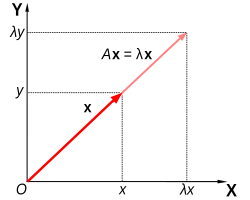

https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors

## Eigenvectors and Eigenvalues of a Covariance Matrix

A **covariance matrix** summarizes how different variables vary together.

In neuroscience and data analysis, it is often computed from population activity or feature vectors.

---

### Eigenvectors

The **eigenvectors** of a covariance matrix represent the **principal directions of variability** in the data.

Each eigenvector defines:

- a direction in the high-dimensional activity space

- along which the data vary independently of other directions

In neuroscience, an eigenvector can be interpreted as a **population activity pattern** shared across neurons.

---

### Eigenvalues

The **eigenvalue** associated with an eigenvector measures the **amount of variance** in the data along that direction.

- Large eigenvalue → strong, reliable pattern of shared activity   

- Small eigenvalue → weak or noisy variation  

---

### Key Relationship

For a covariance matrix $\mathbf{C}$:

$$
\mathbf{C}\mathbf{v} = \lambda \mathbf{v}
$$

- $\mathbf{v}$: eigenvector (direction of variability)  
- $\lambda$: eigenvalue (variance along that direction)

---

### Interpretation

- Eigenvectors define **axes** that best explain the data

- Eigenvalues tell us **how important** each axis is

This is the basis of **Principal Component Analysis (PCA)**, which is widely used to analyze neural population activity.

---

### Summary

Eigenvectors of the covariance matrix define meaningful patterns of activity, and eigenvalues quantify how much variance each pattern explains.


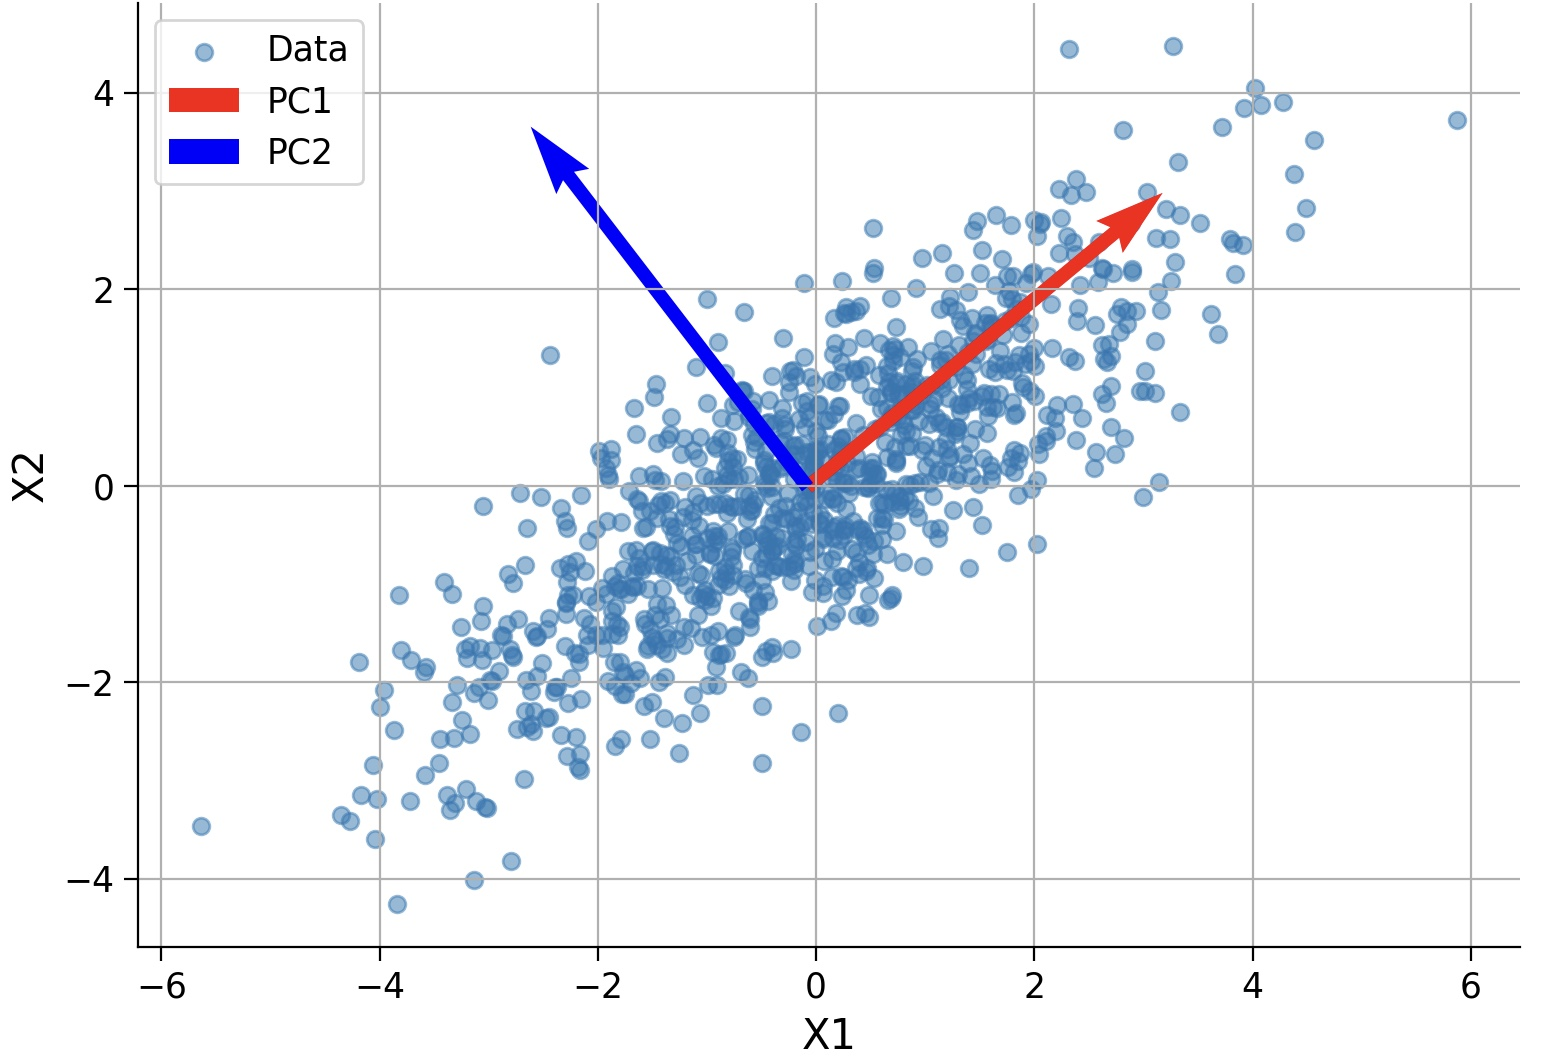

---
# Section 5 Calculus: What is differentiation and integration?


In [ ]:
# @title Install dependencies
!pip install sympy --quiet

In [ ]:
# Imports
import numpy as np
import scipy.optimize as opt  # import root-finding algorithm
import sympy as sp  # Python toolbox for symbolic maths
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Toolbox for rendring 3D figures
from mpl_toolkits import mplot3d  # Toolbox for rendring 3D figures

In [ ]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
from ipywidgets import interact
%config InlineBackend.figure_format = 'retina'
# use NMA plot style
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")
my_layout = widgets.Layout()

fig_w, fig_h = 12, 4.5
my_fontsize = 16
my_params = {'axes.labelsize': my_fontsize,
          'axes.titlesize': my_fontsize,
          'figure.figsize': [fig_w, fig_h],
          'font.size': my_fontsize,
          'legend.fontsize': my_fontsize-4,
          'lines.markersize': 8.,
          'lines.linewidth': 2.,
          'xtick.labelsize': my_fontsize-2,
          'ytick.labelsize': my_fontsize-2}

plt.rcParams.update(my_params)

In [ ]:
# @title Plotting Functions
def move_sympyplot_to_axes(p, ax):
    backend = p.backend(p)
    backend.ax = ax
    backend.process_series()
    backend.ax.spines['right'].set_color('none')
    backend.ax.spines['bottom'].set_position('zero')
    backend.ax.spines['top'].set_color('none')
    plt.close(backend.fig)


def plot_functions(function, show_derivative, show_integral):

  # For sympy we first define our symbolic variable
  x, y, z, t, f = sp.symbols('x y z t f')

  # We define our function
  if function == 'Linear':
    f = -2*t
    name = r'$-2t$'
  elif function == 'Parabolic':
    f =  t**2
    name = r'$t^2$'
  elif function == 'Exponential':
    f =  sp.exp(t)
    name = r'$e^t$'
  elif function == 'Sine':
    f =  sp.sin(t)
    name = r'$sin(t)$'
  elif function == 'Sigmoid':
    f = 1/(1 + sp.exp(-(t-5)))
    name = r'$\frac{1}{1+e^{-(t-5)}}$'

  if show_derivative and not show_integral:
    # Calculate the derivative of sin(t) as a function of t
    diff_f = sp.diff(f)
    print('Derivative of', f, 'is ', diff_f)

    p1 = sp.plot(f, diff_f, show=False)
    p1[0].line_color='r'
    p1[1].line_color='b'
    p1[0].label='Function'
    p1[1].label='Derivative'
    p1.legend=True
    p1.title = 'Function = ' + name + '\n'
    p1.show()
  elif show_integral and not show_derivative:

    int_f = sp.integrate(f)
    int_f = int_f - int_f.subs(t, -10)
    print('Integral of', f, 'is ', int_f)


    p1 = sp.plot(f, int_f, show=False)
    p1[0].line_color='r'
    p1[1].line_color='g'
    p1[0].label='Function'
    p1[1].label='Integral'
    p1.legend=True
    p1.title = 'Function = ' + name + '\n'
    p1.show()


  elif show_integral and show_derivative:

    diff_f = sp.diff(f)
    print('Derivative of', f, 'is ', diff_f)

    int_f = sp.integrate(f)
    int_f = int_f - int_f.subs(t, -10)
    print('Integral of', f, 'is ', int_f)

    p1 = sp.plot(f, diff_f, int_f, show=False)
    p1[0].line_color='r'
    p1[1].line_color='b'
    p1[2].line_color='g'
    p1[0].label='Function'
    p1[1].label='Derivative'
    p1[2].label='Integral'
    p1.legend=True
    p1.title = 'Function = ' + name + '\n'
    p1.show()

  else:

    p1 = sp.plot(f, show=False)
    p1[0].line_color='r'
    p1[0].label='Function'
    p1.legend=True
    p1.title = 'Function = ' + name + '\n'
    p1.show()


def plot_alpha_func(t, f, df_dt):

  plt.figure()
  plt.subplot(2,1,1)
  plt.plot(t, f, 'r', label='Alpha function')
  plt.xlabel('Time (au)')
  plt.ylabel('Voltage')
  plt.title('Alpha function (f(t))')
  #plt.legend()

  plt.subplot(2,1,2)
  plt.plot(t, df_dt, 'b', label='Derivative')
  plt.title('Derivative of alpha function')
  plt.xlabel('Time (au)')
  plt.ylabel('df/dt')
  #plt.legend()


def plot_charge_transfer(t, PSP, numerical_integral):

  fig, axes = plt.subplots(1, 2)

  axes[0].plot(t, PSP)
  axes[0].set(xlabel = 't', ylabel = 'PSP')

  axes[1].plot(t, numerical_integral)
  axes[1].set(xlabel = 't', ylabel = 'Charge Transferred')

##  Section 5.1: Interactive Demo: Geometrical understanding

In the interactive demo below, you can pick different functions to examine in the drop-down menu. You can then choose to show the derivative function and/or the integral function.

For the integral, we have chosen the unknown constant $C$ such that the integral function at the left x-axis limit is $0$, as $f(t = -10) = 0$. So the integral will reflect the area under the curve starting from that position.

For each function:

* Examine just the function first. Discuss and predict what the derivative and integral will look like. Remember that _derivative = slope of the function_, _integral = area under the curve from $t = -10$ to that $t$_.
* Check the derivative - does it match your expectations?
* Check the integral - does it match your expectations?

In [ ]:
# @markdown Execute this cell to enable the widget
function_options = widgets.Dropdown(
    options=['Linear', 'Exponential', 'Sine', 'Sigmoid'],
    description='Function',
    disabled=False,
)

derivative = widgets.Checkbox(
    value=False,
    description='Show derivative',
    disabled=False,
    indent=False
)

integral = widgets.Checkbox(
    value=False,
    description='Show integral',
    disabled=False,
    indent=False
)

def on_value_change(change):
    derivative.value = False
    integral.value = False

function_options.observe(on_value_change, names='value')

interact(plot_functions, function = function_options, show_derivative = derivative, show_integral = integral);

interactive(children=(Dropdown(description='Function', options=('Linear', 'Exponential', 'Sine', 'Sigmoid'), v…

## Section 5.2: Transfer Function and Gain of a Neuron (Derivative of the transfer function)

When we inject a constant current (DC) into a neuron, its firing rate changes as a function of the strength of the injected current. This is called the **input-output transfer function** or just the *transfer function* or *I/O Curve* of the neuron. For most neurons, this can be approximated by a sigmoid function, e.g.:

\begin{equation}
rate(I) = \frac{1}{1+\text{exp}(-a \cdot (I-\theta))} - \frac{1}{\text{exp}(a \cdot \theta)} + \eta
\end{equation}

where $I$ is injected current, $rate$ is the neuron firing rate and $\eta$ is noise (Gaussian noise with zero mean and $\sigma$ standard deviation).

The slope of a neuron input-output transfer function, i.e., $\frac{d(r(I))}{dI}$, is called the **gain** of the neuron, as it tells how the neuron output will change if the input is changed. In other words, the slope of the transfer function tells us in which range of inputs the neuron output is most sensitive to changes in its input.

### Interactive Demo: Calculating the Transfer Function and Gain of a Neuron

In the following demo, you can estimate the gain of the following neuron transfer function using numerical differentiation. We will use our timestep as h. See the cell below for a function that computes the rate via the formula above and then the gain using numerical differentiation. In the following cell, you can play with the parameters $a$ and $\theta$ to change the shape of the transfer function (and see the resulting gain function). You can also set $I_{mean}$ to see how the slope is computed for that value of I. In the left plot, the red vertical lines are the two values of the current being used to calculate the slope, while the blue lines point to the corresponding output firing rates.

Change the parameters of the neuron transfer function (i.e., $a$ and $\theta$) and see if you can predict the value of $I$ for which the neuron has a maximal slope and which parameter determines the peak value of the gain. Ensure you understand how the right plot relates to the left.


In [ ]:
def compute_rate_and_gain(I, a, theta, current_timestep):
  """ Compute rate and gain of neuron based on parameters

  Args:
    I (ndarray): different possible values of the current
    a (scalar): parameter of the transfer function
    theta (scalar): parameter of the transfer function
    current_timestep (scalar): the time we're using to take steps

  Returns:
    (ndarray, ndarray): rate and gain for each possible value of I
  """

  # Compute rate
  rate = (1+np.exp(-a*(I-theta)))**-1 - (1+np.exp(a*theta))**-1

  # Compute gain using a numerical derivative
  gain = (rate[1:] - rate[0:-1])/current_timestep

  return rate, gain

In [ ]:
# @markdown Execute this cell to enable the widget

def plot_rate_and_gain(a, theta, I_mean):

  current_timestep = 0.1

  # Compute I
  I = np.arange(0, 8, current_timestep)

  rate, gain = compute_rate_and_gain(I, a, theta, current_timestep)
  I_1 = I_mean - current_timestep/2
  rate_1 = (1+np.exp(-a*(I_1-theta)))**-1 - (1+np.exp(a*theta))**-1
  I_2 = I_mean + current_timestep/2
  rate_2 = (1+np.exp(-a*(I_2-theta)))**-1 - (1+np.exp(a*theta))**-1

  input_range = I_2-I_1
  output_range = rate_2 - rate_1

  # Visualize rate and gain
  plt.subplot(1,2,1)
  plt.plot(I,rate)
  plt.plot([I_1,I_1],[0, rate_1],color='r')
  plt.plot([0,I_1],[rate_1, rate_1],color='b')
  plt.plot([I_2,I_2],[0, rate_2],color='r')
  plt.plot([0,I_2],[rate_2, rate_2],color='b')
  plt.xlim([0, 8])
  low, high = plt.ylim()
  plt.ylim([0, high])

  plt.xlabel('Injected current (au)')
  plt.ylabel('Output firing rate (normalized)')
  plt.title('Transfer function')

  plt.text(2, 1.3, 'Output-Input Ratio =' + str(np.round(1000*output_range/input_range)/1000), style='italic',
      bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
  plt.subplot(1,2,2)
  plt.plot(I[0:-1], gain)
  plt.plot([I_mean, I_mean],[0,0.6],color='r')
  plt.xlabel('Injected current (au)')
  plt.ylabel('Gain')
  plt.title('Gain')
  plt.xlim([0, 8])
  low, high = plt.ylim()
  plt.ylim([0, high])

_ = widgets.interact(plot_rate_and_gain, a = (0.5, 2.0, .02), theta=(1.2,4.0,0.1), I_mean= (0.5,8.0,0.1))

interactive(children=(FloatSlider(value=1.24, description='a', max=2.0, min=0.5, step=0.02), FloatSlider(value…

# Question 4

1. How does $\theta$ affect the transfer function and gain?

2. How does $a$ affect the transfer function and gain?

1. Theta is the threshold/shift parameter, raising theta moves the whole transfer function to the right (you need more injected current to get the same firing rate), lowering theta shifts it to the left. The gain curve (the slope/derivative) shifts the same way: its peak occurs near I=theta, so increasing theta moves the gain peak to higher current.

2. a controls the steepness, larger a makes the sigmoid transition sharper (more “switch-like”), smaller a makes it more gradual. Since gain is essentially the slope, larger a produces a taller, narrower gain peak (higher maximum gain over a smaller current range), while smaller a produces a shorter, wider peak (lower maximum gain spread over a larger range).

### Interactive Demo: Riemann Sum vs. Analytical Integral with changing step size

Below, we will compare numerical integration using the Riemann Sum with the analytical solution. You can change the interval size $dt$ using the slider.


In [ ]:
# @markdown Run this cell to enable the widget!
def riemann_sum_demo(dt = 0.5):
  step_size = 0.1
  min_val = 0.
  max_val = 10.
  tx = np.arange(min_val, max_val, step_size)

  # Our function
  ftn = tx**2 - tx + 1
  # And the integral analytical formula calculates using sympy
  int_ftn = tx**3/3 - tx**2/2 + tx

  # Numerical integration of f(t) using Riemann Sum
  n = int((max_val-min_val)/dt)
  r_tx = np.zeros(n)
  fun_value = np.zeros(n)
  for ii in range(n):
    a = min_val+ii*dt
    fun_value[ii] = a**2 - a + 1
    r_tx[ii] = a;

  # Riemann sum is just cumulative sum of the fun_value multiplied by the
  r_sum = np.cumsum(fun_value)*dt
  with plt.xkcd():
    plt.figure(figsize=(20,5))
    ax = plt.subplot(1,2,1)
    plt.plot(tx,ftn,label='Function')

    for ii in range(n):
      plt.plot([r_tx[ii], r_tx[ii], r_tx[ii]+dt, r_tx[ii]+dt], [0, fun_value[ii], fun_value[ii], 0] ,color='r')

    plt.xlabel('Time (au)')
    plt.ylabel('f(t)')
    plt.title('f(t)')
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(tx,int_ftn,label='Analytical')
    plt.plot(r_tx+dt,r_sum,color = 'r',label='Riemann Sum')
    plt.xlabel('Time (au)')
    plt.ylabel('int(f(t))')
    plt.title('Integral of f(t)')
    plt.grid()
    plt.legend()
    plt.show()


_ = widgets.interact(riemann_sum_demo, dt = (0.1, 1., .02))

interactive(children=(FloatSlider(value=0.5, description='dt', max=1.0, min=0.1, step=0.02), Output()), _dom_c…

## Section 5.3 Using integration to calculate the total charge transfer with excitatory input

An incoming spike elicits a change in the post-synaptic membrane potential (PSP), which can be captured by the following function:

\begin{equation}
PSP(t) = J \cdot t \cdot \text{exp}\left(-\frac{t-t_{sp}}{\tau_{s}}\right)
\end{equation}

where $J$ is the synaptic amplitude, $t_{sp}$ is the spike time and $\tau_s$ is the synaptic time constant.

We want to estimate the total charge transferred to the postsynaptic neuron during a PSP with amplitude $J=1.0$, $\tau_s = 1.0$ and $t_{sp} = 1$ (that is the spike occurred at $1$ ms). The total charge will be the integral of the PSP function.

For this example, we may estimate by doing the following calculations:

An incoming spike elicits a post-synaptic potential (PSP) given by

$$
\mathrm{PSP}(t) = J \, t \, \exp\!\left(-\frac{t - t_{sp}}{\tau_s}\right),
$$

where $J$ is the synaptic amplitude, $t_{sp}$ is the spike time, and $\tau_s$ is the synaptic time constant.

The total charge transferred to the postsynaptic neuron is given by the time integral of the PSP:

$$
Q = \int_{t_{sp}}^{\infty} \mathrm{PSP}(t)\, dt
$$

Substituting $J = 1.0$, $\tau_s = 1.0$, and $t_{sp} = 1$, we obtain

$$
Q = \int_{1}^{\infty} t \, e^{-(t-1)} \, dt
$$

Let $u = t - 1$, so that $t = u + 1$ and $dt = du$. Then

$$
Q = \int_{0}^{\infty} (u+1) e^{-u} \, du
= \int_{0}^{\infty} u e^{-u} \, du + \int_{0}^{\infty} e^{-u} \, du.
$$

Using standard integrals,

$$
\int_{0}^{\infty} u e^{-u} \, du = 1
\qquad
\int_{0}^{\infty} e^{-u} \, du = 1
$$

Therefore

$$
Q = 2
$$


# Coding Exercise 3

Alternatively, we can compute the charge transfered by evaluating the integration using Python code

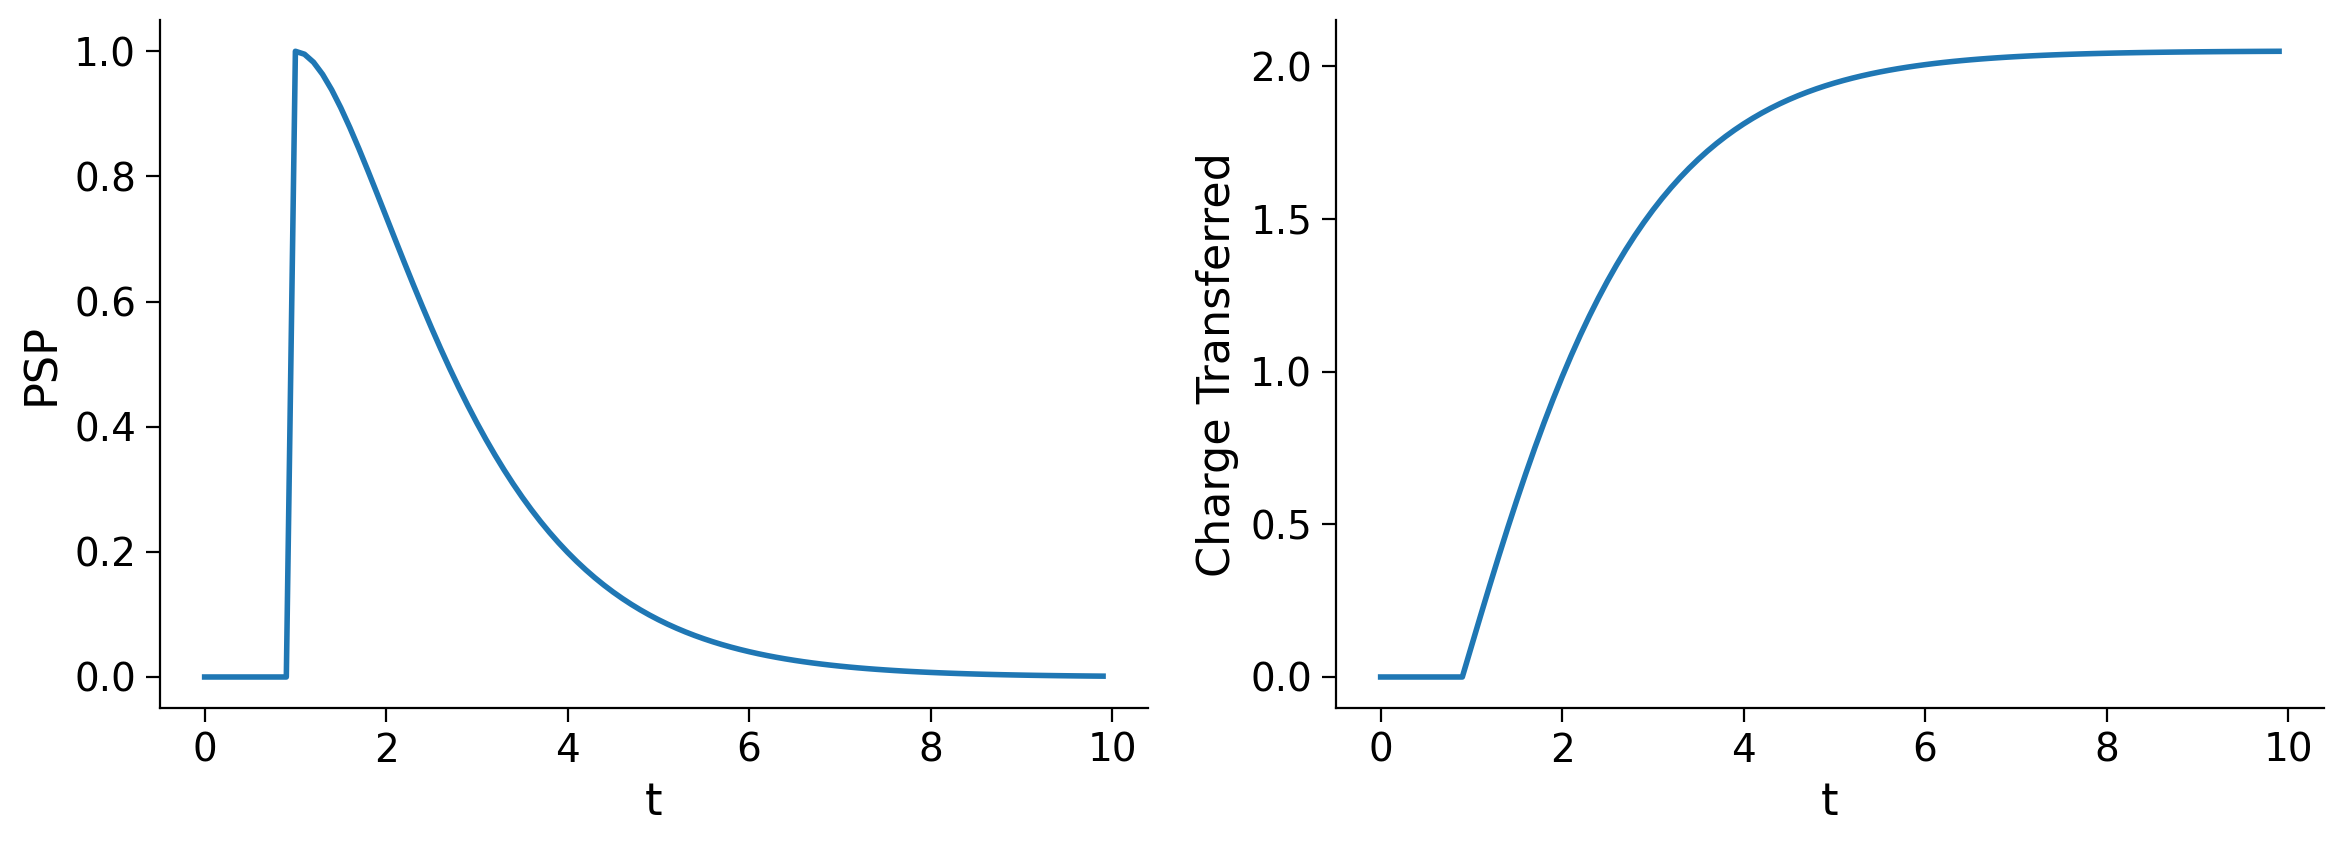

In [ ]:
########################################################################
## TODO for students
## Complete all ... in code below and remove
# raise NotImplementedError("Calculate the charge transfer")
########################################################################

# Set up parameters
J = 1
tau_s = 1
t_sp = 1
dt = .1
t = np.arange(0, 10, dt)

# Code PSP formula
PSP = J*t*np.exp(-(t-t_sp)/tau_s)

PSP[t < t_sp] = 0.0  # enforce causality

# Compute numerical integral
# We already have PSP at every time step (height of rectangles). We need to
# multiply by width of rectangles (dt) to get areas
rectangle_areas = PSP*dt

# Cumulatively sum rectangles (hint: use np.cumsum)
numerical_integral = np.cumsum(rectangle_areas)

# Visualize
plot_charge_transfer(t, PSP, numerical_integral)

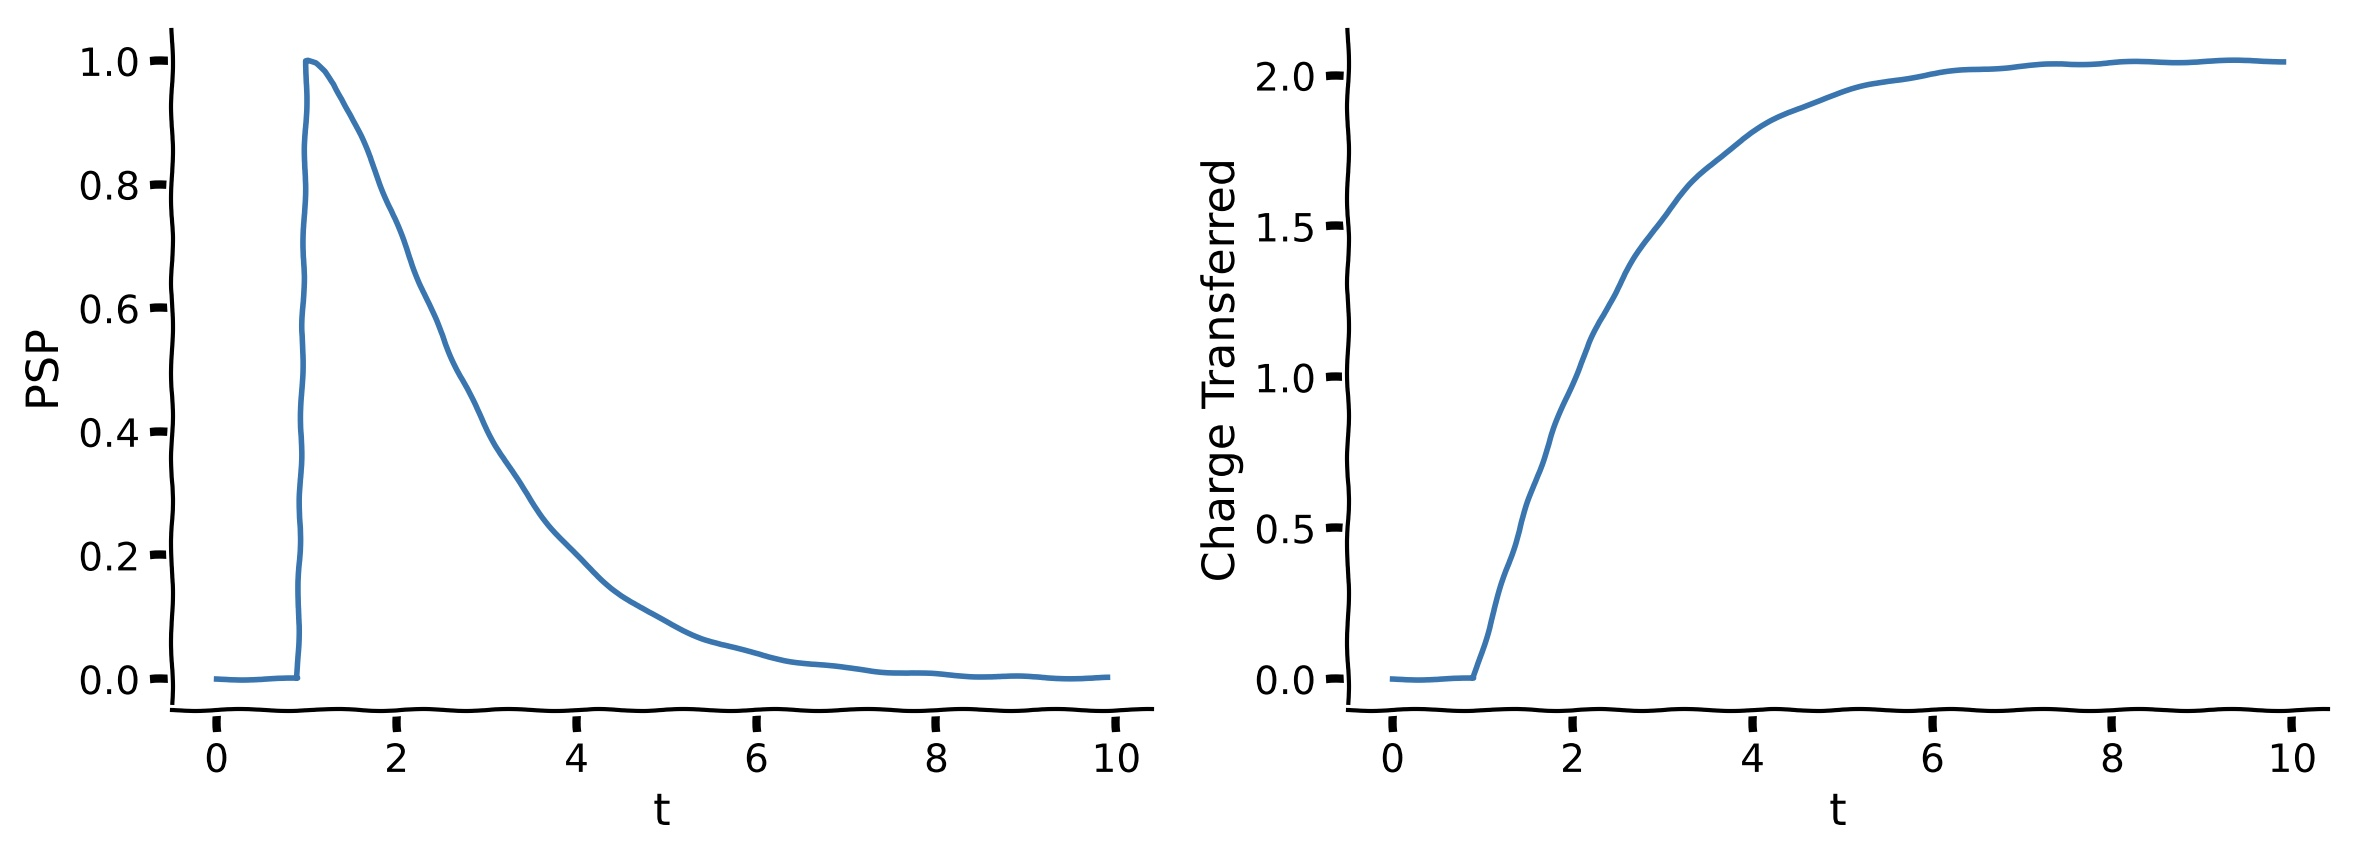

You can see from the figure that the total charge transferred is around 2.

# Section 6 Partial Derivatives

In the previous section, you looked at function of single variable $t$ or $x$. In most cases, we encounter functions of multiple variables.  

For example, in the brain, the firing rate of a neuron is a function of both excitatory and inhibitory input rates. In the following, we will look into how to calculate derivatives of such functions.

When we take the derrivative of a multivariable function with respect to one of the variables it is called the **partial derivative**. For example if we have a function:

\begin{align}
f(x,y) = x^2 + 2xy + y^2
\end{align}

The we can define the partial derivatives as

\begin{align}
\frac{\partial(f(x,y))}{\partial x} = 2x + 2y + 0 \\\\
\frac{\partial(f(x,y))}{\partial y} = 0 + 2x + 2y
\end{align}

In the above, the derivative of the last term ($y^2$) with respect to $x$ is zero because it does not change with respect to $x$. Similarly, the derivative of $x^2$ with respect to $y$ is also zero.

### Interactive Demo: Visualize partial derivatives

In the demo below, you can input any function of $x$ and $y$ and then visualize both the function and partial derivatives.

We visualized the 2-dimensional function as a surface plot in which the function values are rendered as color.

Yellow represents a high value, and blue represents a low value. The height of the surface also shows the numerical value of the function.

The first plot is that of our function. And the two bottom plots are the derivative surfaces with respect to $x$ and $y$ variables.

Ensure you understand how the plots relate to each other


In [ ]:
# @markdown Execute this widget to enable the demo

# Let's use sympy to calculate Partial derivatives of a function of 2-variables
@interact(f2d_string = 'x**2 + 2*x*y + y**2')
def plot_partial_derivs(f2d_string):
  f, x, y = sp.symbols('f, x, y')

  f2d = eval(f2d_string)
  f2d_dx = sp.diff(f2d,x)
  f2d_dy = sp.diff(f2d,y)

  print('Partial derivative of ', f2d, 'with respect to x is', f2d_dx)
  print('Partial derivative of ', f2d, 'with respect to y is', f2d_dy)

  p1 = sp.plotting.plot3d(f2d, (x, -5, 5), (y, -5, 5),show=True,xlabel='x', ylabel='y', zlabel='f(x,y)',title='Our function')

  p2 = sp.plotting.plot3d(f2d_dx, (x, -5, 5), (y, -5, 5),show=True,xlabel='x', ylabel='y', zlabel='df(x,y)/dx',title='Derivative w.r.t. x')

  p3 = sp.plotting.plot3d(f2d_dy, (x, -5, 5), (y, -5, 5),show=True,xlabel='x', ylabel='y', zlabel='df(x,y)/dy',title='Derivative w.r.t. y')

interactive(children=(Text(value='x**2 + 2*x*y + y**2', description='f2d_string'), Output()), _dom_classes=('w…

# Question 5

What is the vector $\left( \frac{\partial(f(x,y))}{\partial x}, \frac{\partial(f(x,y))}{\partial y} \right)$ representing?

The vector is the gradient of f. It points in the direction of steepest increase of the function, and its magnitude tells us how fast f increases in that direction.